# Tiled clustering model
 
This example is similar as the example presented in Figure 1 in Covariate-moderated Empirical Bayes Matrix Factorization  Denault et al 2025  Matrix Factorization
 
**Model description:**


We simulate a matrix $Z=LF^t$  in which $  L $ (but not $  F $) depended on the
2-d locations of the data points. Specifically, we generated a
periodic tiling of $[0,1] \times [0,1]$, randomly labeling each tile
1, 2 or 3. For each data point $i$, we set
$\ell_{ik} = f(x,y)$ if $i$ was in the tile with label $k$, otherwise
$\ell_{ik} = 0$. The $  F $ matrix, by contrast, was simulated from
a simple scale mixture of normals, $f_{jk} \sim \pi_0 \delta_0 +
\sum_{m=1}^M N(0, \sigma_m^2)$. We simulated homoskedastic noise with
$\tau_{ij} = 0.1$.
 

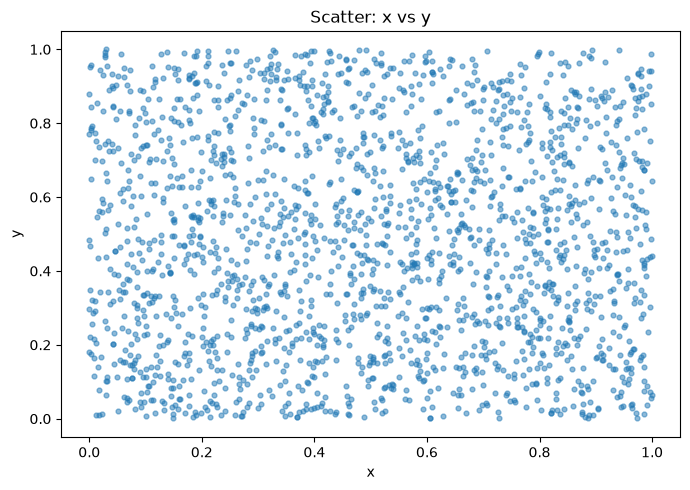

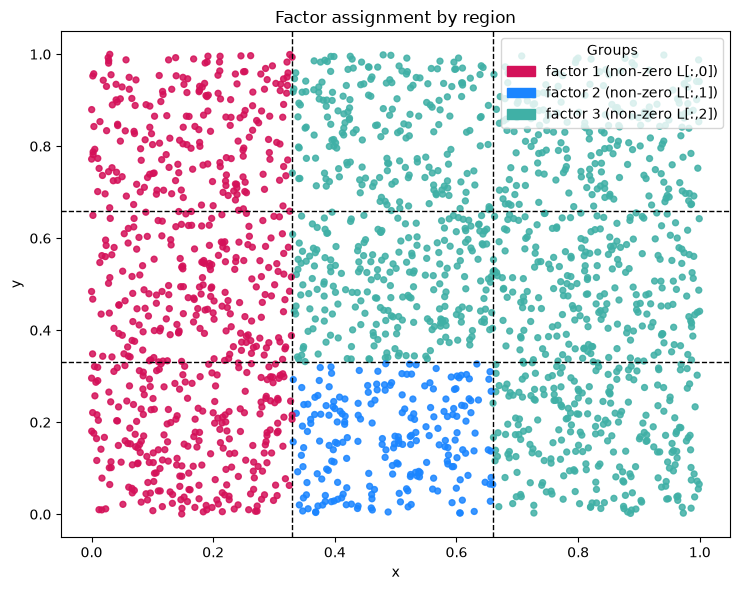

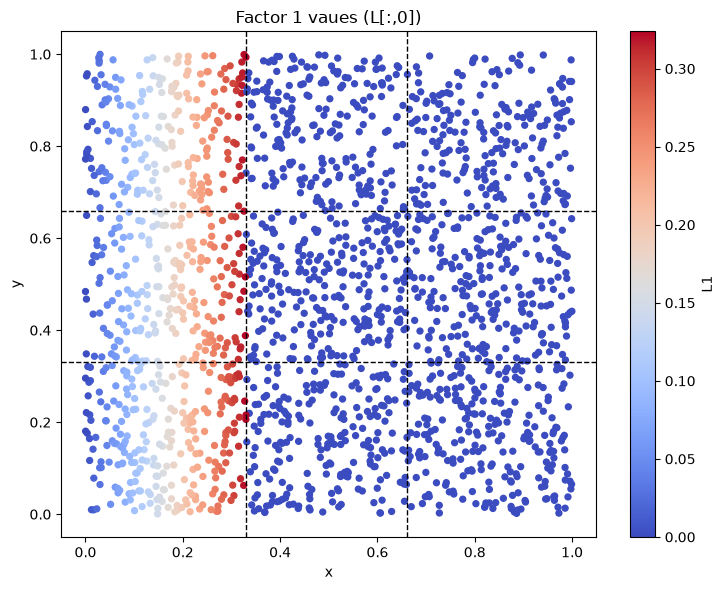

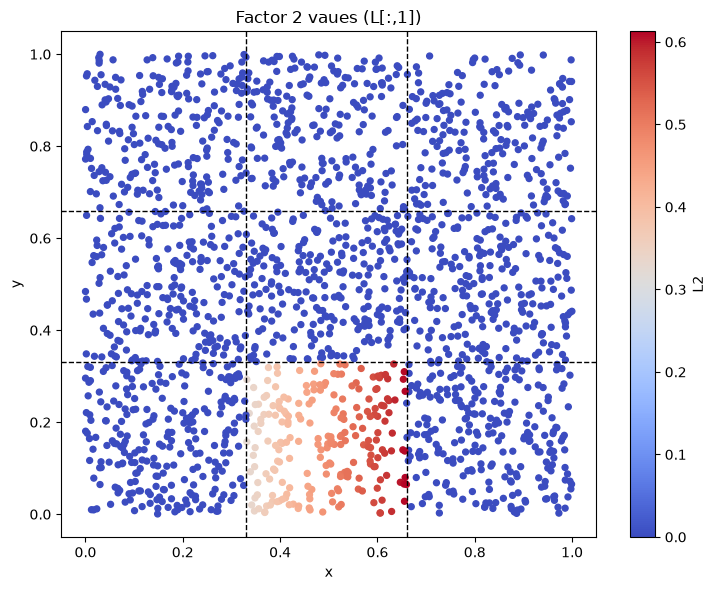

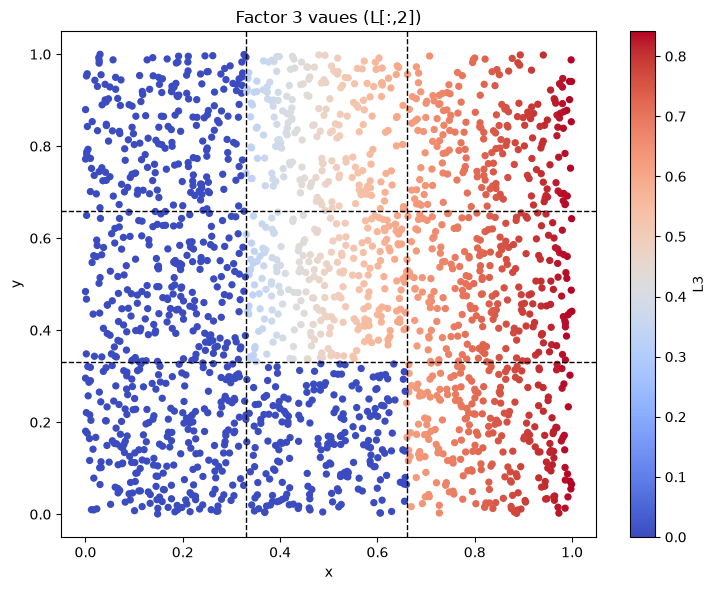

In [1]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# =========================
# Config & Reproducibility
# =========================
SEED = 1
N = 2000          # number of (x,y) points
M = 200           # number of features (columns) in f
BOUNDARIES = (0.33, 0.66)  # vertical/horizontal guide lines
NOISE_STD = 1.0   # std-dev for observation noise in Z

torch.manual_seed(SEED)

# =========================
# 1) Random uniform data
# =========================
x = torch.rand(N)
y = torch.rand(N)
X = torch.stack([x, y], dim=1)  # (N, 2) -- kept for clarity/optionally used later

# Quick scatter of x vs y
plt.figure(figsize=(7, 5))
plt.scatter(x.numpy(), y.numpy(), alpha=0.5, s=12)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter: x vs y")
plt.tight_layout()
plt.show()

# =========================
# 2) Generate f (3 x M)
#    f[0,i] ~ t1_i * N(0,1), f[1,i], f[2,i] ~ t2_i * N(0,1)
# =========================
t1 = torch.randint(0, 2, (M,), dtype=torch.float32)  # {0,1}
t2 = torch.randint(0, 2, (M,), dtype=torch.float32)  # {0,1}

f0 = t1 * torch.randn(M)
f1 = t2 * torch.randn(M)
f2 = t2 * torch.randn(M)
f  = torch.stack([f0, f1, f2], dim=0)  # (3, M)

# =========================
# 3) Build L (N x 3) + factor labels
# =========================
L = torch.zeros(N, 3, dtype=torch.float32)

b1, b2 = BOUNDARIES
mask1 = x < b1
mask2 = (~mask1) & (x < b2) & (y < b1)  # second region
mask3 = ~(mask1 | mask2)                # everything else

# Nonzero loadings by region (note: original logic used sin(x) for all three)
L[mask1, 0] = torch.sin(x[mask1])
L[mask2, 1] = torch.sin(x[mask2])
L[mask3, 2] = torch.sin(x[mask3])

# Integer factor labels in {1,2,3}
factor = torch.zeros(N, dtype=torch.long)
factor[mask1] = 1
factor[mask2] = 2
factor[mask3] = 3

# =========================
# 4) Factor visualization
# =========================
colors = ["#D41159", "#1A85FF", "#40B0A6"]  # red, blue, teal
color_map = {1: colors[0], 2: colors[1], 3: colors[2]}
point_colors = [color_map[int(k)] for k in factor.tolist()]

plt.figure(figsize=(7.5, 6))
plt.scatter(x.numpy(), y.numpy(), c=point_colors, s=18, alpha=0.85)
for v in (b1, b2):
    plt.axhline(v, color="black", linestyle="--", linewidth=1)
    plt.axvline(v, color="black", linestyle="--", linewidth=1)
plt.title("Factor assignment by region")
plt.xlabel("x")
plt.ylabel("y")

# Legend (explicit: red = non-zero L[:,0], etc.)
handles = [
    mpatches.Patch(color=colors[0], label="factor 1 (non-zero L[:,0])"),
    mpatches.Patch(color=colors[1], label="factor 2 (non-zero L[:,1])"),
    mpatches.Patch(color=colors[2], label="factor 3 (non-zero L[:,2])"),
]
plt.legend(handles=handles, title="Groups", loc="best", frameon=True)
plt.tight_layout()
plt.show()

# =========================
# 5) Individual factor heatmaps (L1, L2, L3 as color)
# =========================
for i in range(3):
    plt.figure(figsize=(7.5, 6))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=L[:, i].numpy(),
        cmap="coolwarm",  # shows magnitude of L[:,i]
        s=18
    )
    for v in (b1, b2):
        plt.axhline(v, color="black", linestyle="--", linewidth=1)
        plt.axvline(v, color="black", linestyle="--", linewidth=1)
    plt.title(f"Factor {i+1} vaues (L[:,{i}])")
    plt.xlabel("x")
    plt.ylabel("y")
    cbar = plt.colorbar()
    cbar.set_label(f"L{i+1}")
    plt.tight_layout()
    plt.show()

# =========================
# 6) Generate observations Z = L @ f + noise
# =========================
noise = NOISE_STD * torch.randn(N, M)
Z = L @ f + noise  # (N, M)

# Optional sanity checks
assert L.shape == (N, 3)
assert f.shape == (3, M)
assert Z.shape == (N, M)


We will factorize the matrix Z using 4 different models.


* EBMF using point mass Laplace without using side information
* cEBMF using a "covariate moderated adaptive shrinkage prior " (cash) $ g(x,y) = \pi_0(x,y) \delta_0 + \sum_{m=1}^M \pi_m (x,y) N(0, \sigma_m^2)  $
* cEBMF using a "covariate moderated generalized binary prior" (cbg) $ g(x,y) = \pi_0(x,y) \delta_0 + (1-\pi_0(x,y))  N(\mu, \sigma_m^2)  $
* cEBMF using a "emprirical mixture of density networks" (emdn) $ g(x,y) = \  \sum_{m=1}^M \pi_m (x,y) N(\mu(x,y), \sigma_m(x,y)^2)  $

Fitting the model without account for the 2d side information

In [2]:
from cebmf_torch import cEBMF
mycebmf=  cEBMF(data=Z ) 
mycebmf.initialise_factors()
mycebmf.fit(10)

CEBMFResult(L=tensor([[-6.7597e+00, -1.4332e-02,  1.8322e+00,  7.4405e-09, -1.7140e-07],
        [-1.2728e-01, -8.6279e-02,  2.0286e+00,  5.9873e-08, -7.0834e-08],
        [-1.6565e+00, -1.5823e-02, -1.1584e-02, -3.5372e-08, -4.6365e-07],
        ...,
        [-6.3494e+00, -9.7500e-01,  1.8474e-02, -1.5801e-08,  5.3093e-07],
        [-1.1016e-01,  6.2749e-02,  2.8442e+00,  6.9965e-08, -1.3878e-08],
        [-9.9254e-02,  1.2566e-01,  1.3082e+00, -2.2994e-08,  6.5559e-08]],
       device='cuda:0'), F=tensor([[-1.3574e-01,  1.4970e-01, -8.4927e-02,  1.7704e-20, -9.3584e-20],
        [ 1.6497e-01,  1.4325e-01,  3.9474e-04,  6.8254e-22, -4.8811e-20],
        [-5.1116e-04, -6.7893e-04,  5.7606e-02,  1.2307e-20, -2.6547e-19],
        [-5.5548e-02,  1.2525e-01,  6.6624e-02, -6.7906e-20,  2.1912e-20],
        [ 1.5923e-05, -2.8374e-02,  6.6554e-02, -1.0835e-19, -7.5139e-20],
        [ 1.1018e-03,  1.7564e-03, -4.5967e-04,  6.2161e-21,  1.4430e-20],
        [-1.2126e-05, -9.3931e-03, -5.1897e-0

In [3]:
mycebmf31=  cEBMF(data=Z, X_l=X,
                 prior_L="cgb_sharp" , allow_backfitting=False) 
mycebmf31.initialise_factors()
mycebmf31.fit(10)

 

[CGB] Epoch 10/10, Loss=11.2641, mu2=-0.161, sigma2=0.524
[CGB] Epoch 10/10, Loss=2.4535, mu2=-0.168, sigma2=0.283
[CGB] Epoch 10/10, Loss=2.2058, mu2=0.161, sigma2=0.203
[CGB] Epoch 10/10, Loss=1.7803, mu2=-0.008, sigma2=0.073
[CGB] Epoch 10/10, Loss=1.7747, mu2=-0.010, sigma2=0.091
[CGB] Epoch 10/10, Loss=7.2416, mu2=-0.317, sigma2=0.149
[CGB] Epoch 10/10, Loss=-0.0707, mu2=-0.313, sigma2=0.038
[CGB] Epoch 10/10, Loss=-0.0674, mu2=0.295, sigma2=0.005
[CGB] Epoch 10/10, Loss=0.3043, mu2=0.003, sigma2=0.000
[CGB] Epoch 10/10, Loss=0.1102, mu2=-0.000, sigma2=0.000
[CGB] Epoch 10/10, Loss=1.3164, mu2=-0.464, sigma2=0.030
[CGB] Epoch 10/10, Loss=-1.0891, mu2=-0.348, sigma2=0.000
[CGB] Epoch 10/10, Loss=-0.5159, mu2=0.351, sigma2=0.000
[CGB] Epoch 10/10, Loss=-7.3566, mu2=0.003, sigma2=0.000
[CGB] Epoch 10/10, Loss=-10.3205, mu2=0.006, sigma2=0.000
[CGB] Epoch 10/10, Loss=-0.3907, mu2=-0.495, sigma2=0.011
[CGB] Epoch 10/10, Loss=-1.1334, mu2=-0.338, sigma2=0.004
[CGB] Epoch 10/10, Loss=-0.

CEBMFResult(L=tensor([[-0.4916,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.3492,  0.0000,  0.0000],
        [-0.0007,  0.0000,  0.0000,  0.0000,  0.0000],
        ...,
        [-0.4910,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.3502,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.3474,  0.0000,  0.0000]], device='cuda:0'), F=tensor([[-1.8258e+00,  2.2261e+00, -7.0928e-01,  0.0000e+00,  0.0000e+00],
        [ 2.2499e+00,  2.1528e+00,  3.0116e-02,  0.0000e+00,  0.0000e+00],
        [-8.5214e-03, -8.8740e-03,  3.3973e-01,  0.0000e+00,  0.0000e+00],
        [-7.4124e-01,  1.8682e+00,  7.4016e-01,  0.0000e+00,  0.0000e+00],
        [ 4.9940e-04, -5.5623e-01,  5.7460e-01,  0.0000e+00,  0.0000e+00],
        [ 1.9557e-02,  2.6755e-02,  9.6025e-03,  0.0000e+00,  0.0000e+00],
        [-9.7815e-04, -9.6440e-02, -1.1332e-02,  0.0000e+00,  0.0000e+00],
        [-2.6023e+00,  2.1547e+00,  1.8279e-01,  0.0000e+00,  0.0000e+00],
        [-6.3255e-04, 

In [ ]:
plt.plot( torch.stack(mycebmf31.obj).detach().gpu().numpy())

TypeError: expected Tensor as element 0 in argument 0, but got float

Fitting the cEBMF model


Here we store the side information for the rows $L$ in the matrix $X$ that we pass in argument X_l (covariate for L)
Using prior   a "covariate moderated adaptive shrinkage prior " (cash) $ g(x,y) = \pi_0(x,y) \delta_0 + \sum_{m=1}^M \pi_m (x,y) N(0, \sigma_m^2)  $


In [6]:
mycebmf11=  cEBMF(data=Z, X_l=X,
                 prior_L="cash" , allow_backfitting=False) 
mycebmf11.initialise_factors()
mycebmf11.fit(10)


[CASH] Epoch 10/10 | Loss: 336.2305
[CASH] Epoch 10/10 | Loss: 213.0982
[CASH] Epoch 10/10 | Loss: 226.2659
[CASH] Epoch 10/10 | Loss: 214.7892
[CASH] Epoch 10/10 | Loss: 214.3623
[CASH] Epoch 10/10 | Loss: 329.0326
[CASH] Epoch 10/10 | Loss: 201.2456
[CASH] Epoch 10/10 | Loss: 216.4923
[CASH] Epoch 10/10 | Loss: 211.3097
[CASH] Epoch 10/10 | Loss: 209.8963
[CASH] Epoch 10/10 | Loss: 327.6227
[CASH] Epoch 10/10 | Loss: 199.7877
[CASH] Epoch 10/10 | Loss: 214.4952
[CASH] Epoch 10/10 | Loss: 209.3351
[CASH] Epoch 10/10 | Loss: 203.5236
[CASH] Epoch 10/10 | Loss: 326.9260
[CASH] Epoch 10/10 | Loss: 199.1033
[CASH] Epoch 10/10 | Loss: 213.4094
[CASH] Epoch 10/10 | Loss: 205.4584
[CASH] Epoch 10/10 | Loss: 203.3495
[CASH] Epoch 10/10 | Loss: 327.7368
[CASH] Epoch 10/10 | Loss: 199.5677
[CASH] Epoch 10/10 | Loss: 214.8046
[CASH] Epoch 10/10 | Loss: 303.6329
[CASH] Epoch 10/10 | Loss: 678.3797
[CASH] Epoch 10/10 | Loss: 326.3889
[CASH] Epoch 10/10 | Loss: 198.7891
[CASH] Epoch 10/10 | Loss: 2

CEBMFResult(L=tensor([[-6.9773e+00, -8.0680e-28,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [-1.7284e-09,  0.0000e+00,  2.4452e+00,  0.0000e+00,  0.0000e+00],
        [-1.9637e+00,  0.0000e+00, -8.2836e-11,  0.0000e+00,  0.0000e+00],
        ...,
        [-6.5315e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [-5.5828e-12,  4.8761e-32,  3.0436e+00,  0.0000e+00,  0.0000e+00],
        [-1.5567e-15,  2.0482e-30,  1.8043e+00,  0.0000e+00,  0.0000e+00]],
       device='cuda:0'), F=tensor([[-1.3301e-01,  1.5394e-01, -9.3367e-02,  0.0000e+00,  0.0000e+00],
        [ 1.6291e-01,  1.5323e-01,  1.5963e-03,  0.0000e+00,  0.0000e+00],
        [-4.5179e-04, -1.0174e-03,  4.0081e-02,  0.0000e+00,  0.0000e+00],
        [-5.4666e-02,  1.2672e-01,  8.0505e-02,  0.0000e+00,  0.0000e+00],
        [ 1.0267e-05, -3.8439e-02,  7.3664e-02,  0.0000e+00,  0.0000e+00],
        [ 1.0019e-03,  2.7039e-03,  6.0073e-05,  0.0000e+00,  0.0000e+00],
        [-2.3247e-05, -1.1739e-02, -1.0852e-0

The ELBO is not purely monotonic for cEBMF using because the prior learning uses SGD

In [ ]:

plt.plot(torch.stack(mycebmf11.obj).detach().cpu().numpy())

TypeError: expected Tensor as element 0 in argument 0, but got float

Fitting the cEBMF model using a "covariate moderated generalized binary prior" (cbg) $ g(x,y) = \pi_0(x,y) \delta_0 + (1-\pi_0) (x,y) N(\mu, \sigma_m^2)  $
 

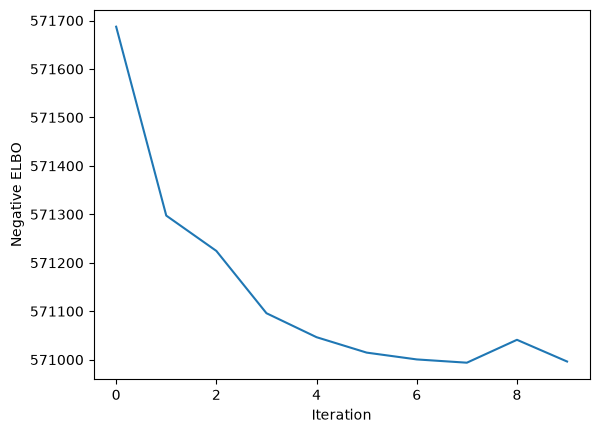

In [15]:
plt.plot(mycebmf11.obj)
plt.xlabel("Iteration")
plt.ylabel("Negative ELBO")
plt.show()

In [ ]:
mycebmf12=  cEBMF(data=Z, X_l=X,
                 prior_L="cgb" , allow_backfitting=False) 
mycebmf12.initialise_factors()
mycebmf12.fit(10)

plt.plot( mycebmf12.obj )

[CGB] Epoch 10/10, Loss=2.7572, mu2=-0.149, sigma2=6.559
[CGB] Epoch 10/10, Loss=1.6915, mu2=-0.101, sigma2=4.403
[CGB] Epoch 10/10, Loss=1.8073, mu2=0.134, sigma2=2.346
[CGB] Epoch 10/10, Loss=1.7332, mu2=-0.016, sigma2=1.533
[CGB] Epoch 10/10, Loss=1.7266, mu2=-0.018, sigma2=1.576
[CGB] Epoch 10/10, Loss=2.7069, mu2=-0.308, sigma2=6.451
[CGB] Epoch 10/10, Loss=1.6218, mu2=-0.250, sigma2=4.359
[CGB] Epoch 10/10, Loss=1.7218, mu2=0.284, sigma2=2.367
[CGB] Epoch 10/10, Loss=1.6903, mu2=-0.040, sigma2=1.754
[CGB] Epoch 10/10, Loss=1.6888, mu2=-0.026, sigma2=1.756
[CGB] Epoch 10/10, Loss=2.6716, mu2=-0.467, sigma2=6.315
[CGB] Epoch 10/10, Loss=1.6070, mu2=-0.405, sigma2=4.288
[CGB] Epoch 10/10, Loss=1.6787, mu2=0.442, sigma2=2.219
[CGB] Epoch 10/10, Loss=1.6685, mu2=-0.071, sigma2=2.265
[CGB] Epoch 10/10, Loss=1.6556, mu2=-0.022, sigma2=2.285
[CGB] Epoch 10/10, Loss=2.6480, mu2=-0.627, sigma2=6.143
[CGB] Epoch 10/10, Loss=1.5935, mu2=-0.557, sigma2=4.135
[CGB] Epoch 10/10, Loss=1.6434, mu

TypeError: expected Tensor as element 0 in argument 0, but got float

Fitting the cEBMF model using a "emprirical mixture of density networks" (emdn) $ g(x,y) = \  \sum_{m=1}^M \pi_m (x,y) N(\mu(x,y), \sigma_m(x,y)^2)  $

In [10]:
mycebmf13=  cEBMF(data=Z, X_l=X,
                 prior_L="emdn", allow_backfitting=False) 
mycebmf13.initialise_factors()
mycebmf13.fit(10)



[EMDN] Epoch 10/10, Loss: 2.8663
[EMDN] Epoch 10/10, Loss: 1.7038
[EMDN] Epoch 10/10, Loss: 1.7084
[EMDN] Epoch 10/10, Loss: 1.6812
[EMDN] Epoch 10/10, Loss: 1.6803
[EMDN] Epoch 10/10, Loss: 1.7212
[EMDN] Epoch 10/10, Loss: 1.5473
[EMDN] Epoch 10/10, Loss: 1.6258
[EMDN] Epoch 10/10, Loss: 1.6923
[EMDN] Epoch 10/10, Loss: 1.6839
[EMDN] Epoch 10/10, Loss: 1.5862
[EMDN] Epoch 10/10, Loss: 1.5171
[EMDN] Epoch 10/10, Loss: 1.4908
[EMDN] Epoch 10/10, Loss: 1.6961
[EMDN] Epoch 10/10, Loss: 1.6777
[EMDN] Epoch 10/10, Loss: 1.5640
[EMDN] Epoch 10/10, Loss: 1.4966
[EMDN] Epoch 10/10, Loss: 1.4702
[EMDN] Epoch 10/10, Loss: 1.7044
[EMDN] Epoch 10/10, Loss: 1.6712
[EMDN] Epoch 10/10, Loss: 1.5462
[EMDN] Epoch 10/10, Loss: 1.4830
[EMDN] Epoch 10/10, Loss: 1.4580
[EMDN] Epoch 10/10, Loss: 1.7079
[EMDN] Epoch 10/10, Loss: 1.6620
[EMDN] Epoch 10/10, Loss: 1.5252
[EMDN] Epoch 10/10, Loss: 1.4849
[EMDN] Epoch 10/10, Loss: 1.4300
[EMDN] Epoch 10/10, Loss: 1.7057
[EMDN] Epoch 10/10, Loss: 1.6488
[EMDN] Epo

CEBMFResult(L=tensor([[-7.2471e+00, -1.9808e-01,  3.7581e-03, -8.3772e-02, -1.8818e-01],
        [-2.6095e-01, -7.4242e-02,  3.5944e+00,  5.2571e-01, -2.8783e-01],
        [-3.8240e+00, -7.1382e-02,  3.3353e-03, -2.6360e-01, -2.0970e-01],
        ...,
        [-6.7233e+00, -9.2415e-02,  1.3159e-02, -2.2706e-01,  5.0419e-01],
        [-3.0862e-01, -3.1041e-02,  3.5608e+00,  3.0905e-01,  8.5518e-01],
        [-3.2204e-01, -2.2057e-02,  3.2080e+00, -1.2557e-01,  2.3628e-01]],
       device='cuda:0'), F=tensor([[-1.3281e-01,  1.6039e-01, -9.7429e-02,  1.2131e-03, -1.9798e-03],
        [ 1.5683e-01,  1.2085e-01,  2.7176e-02, -6.2349e-04, -4.5386e-03],
        [-4.9900e-04, -2.2515e-03,  5.1134e-02,  6.5782e-04, -2.4290e-01],
        [-5.5246e-02,  1.3236e-01,  7.5899e-02, -1.4522e-03, -3.3555e-03],
        [ 7.9212e-05, -3.6376e-02,  7.1349e-02, -1.4627e-03, -1.0567e-03],
        [ 1.2369e-03,  3.1497e-03,  1.3902e-03,  5.8332e-04,  6.2360e-04],
        [ 2.5900e-05, -1.0104e-02, -2.2124e-0

we can visualized the corresponding values to the negative ELBO (lower the better)

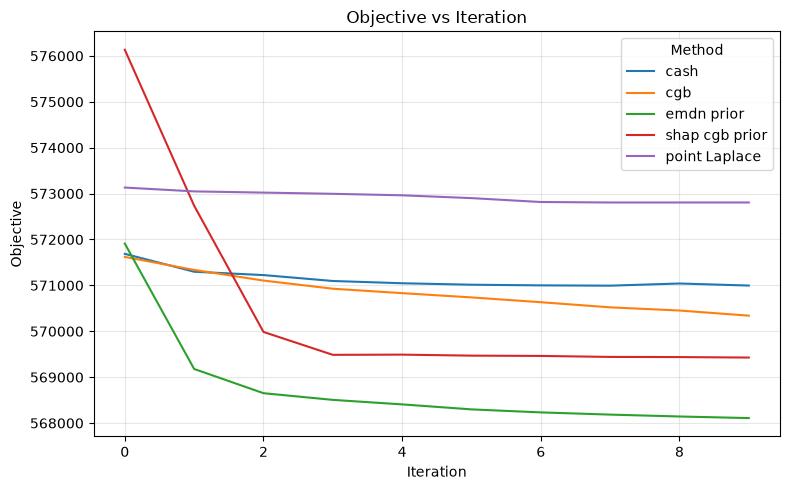

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def to1d(a):
    if isinstance(a, torch.Tensor):
        return a.detach().cpu().flatten().numpy()
    return np.asarray(a).ravel()

fig, ax = plt.subplots(figsize=(8,5))

ax.plot( mycebmf11.obj  , label="cash")
ax.plot( mycebmf12.obj  ,  label="cgb")
ax.plot( mycebmf13.obj ,  label="emdn prior")
ax.plot( mycebmf31.obj ,  label="shap cgb prior")
ax.plot( mycebmf.obj ,   label="point Laplace")

ax.set_title("Objective vs Iteration")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective")
ax.legend(title="Method", loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The results is not surprising as in this case only the emdn prior can recover the data generating process thus leading to a better fit.


The worst is acheived by the EBMF model with point Laplace which is the least flexible model


Noe 

TypeError: unsupported operand type(s) for -: 'numpy.ndarray' and 'Tensor'

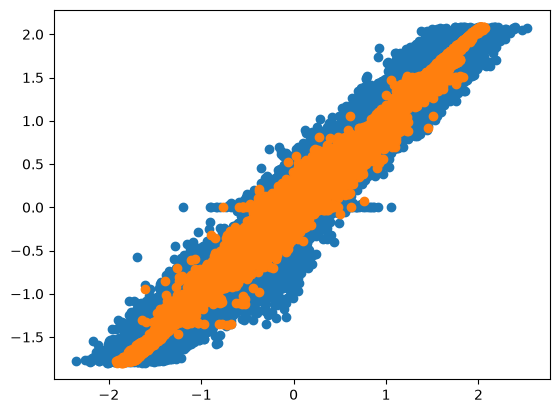

In [19]:
mycebmf._update_fitted_value()
mycebmf11._update_fitted_value()
mycebmf12._update_fitted_value()
mycebmf13._update_fitted_value()
mycebmf31._update_fitted_value()

plt.scatter(mycebmf.Y_fit.detach().cpu().numpy(),L@f)
plt.scatter(mycebmf13.Y_fit.detach().cpu().numpy(),L@f)
print("RMSE Point Laplace",torch.mean((mycebmf.Y_fit.detach().cpu().numpy()-L@f).pow(2)))

print("RMSE cash",torch.mean((mycebmf11.Y_fit.detach().cpu().numpy()-L@f).pow(2)))
print("RMSE cgb",torch.mean((mycebmf12.Y_fit.detach().cpu().numpy()-L@f).pow(2)))
print("RMSE emdn",torch.mean((mycebmf13.Y_fit.detach().cpu().numpy()-L@f).pow(2)))
print("RMSE emdn",torch.mean((mycebmf31.Y_fit.detach().cpu().numpy()-L@f).pow(2)))

Fitted factors (emdn prior)

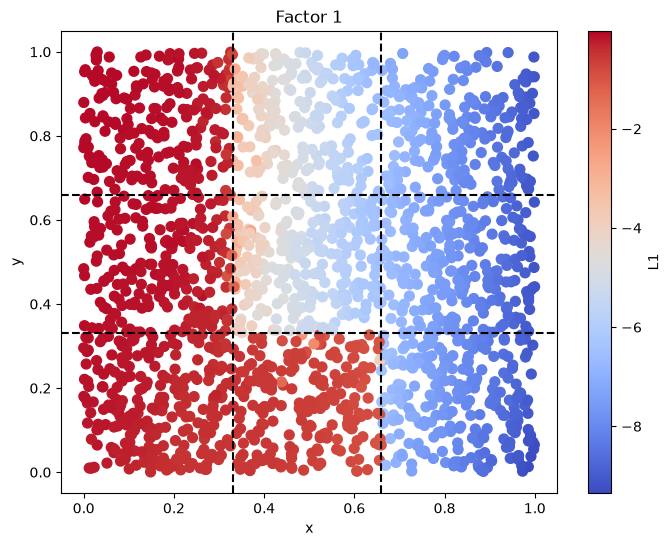

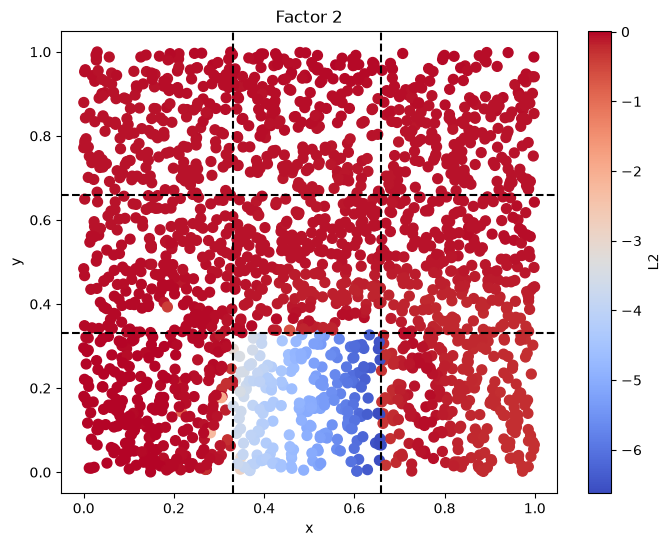

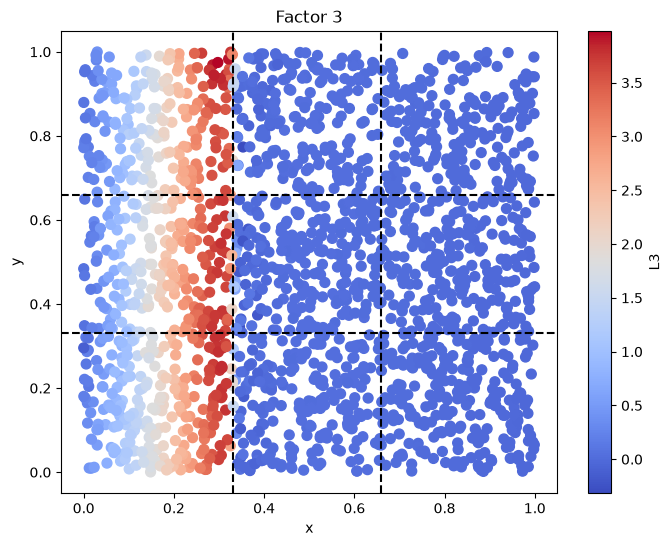

In [20]:
for i in range(3):
    plt.figure(figsize=(8,6))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=mycebmf13.L[:, i].detach().cpu().numpy(),
        cmap="coolwarm",
        s=50
    )
    for v in [0.33, 0.66]:
        plt.axhline(v, color="black", linestyle="--")
        plt.axvline(v, color="black", linestyle="--")
    plt.title(f"Factor {i+1}")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar(label=f"L{i+1}")
    plt.show()


Fitted factors (point Laplace)

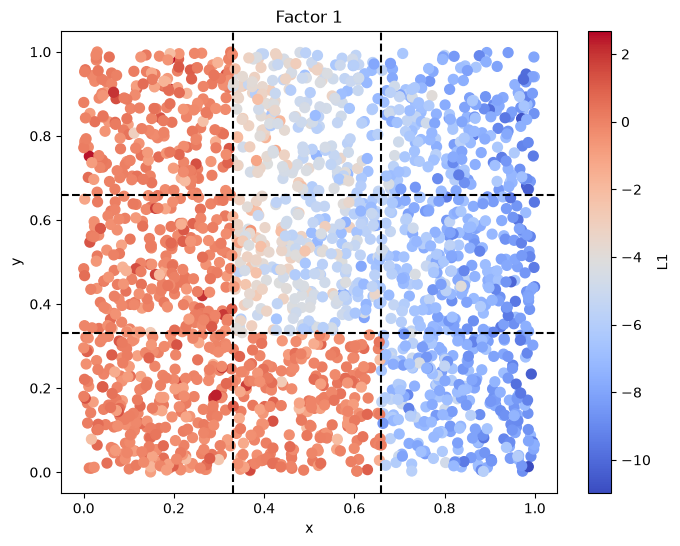

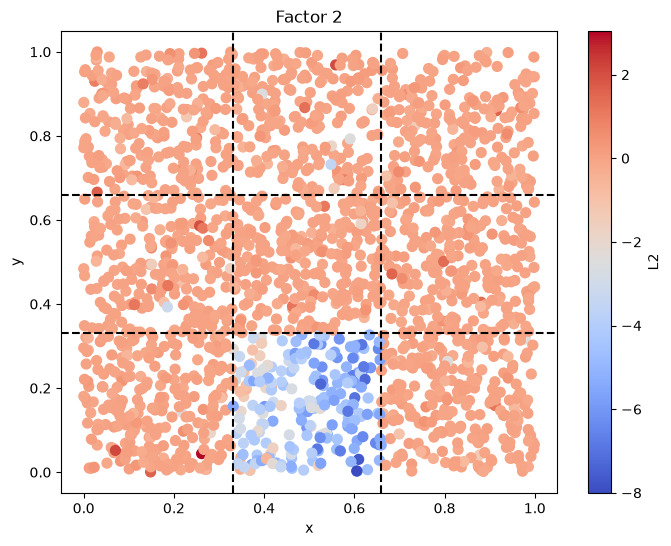

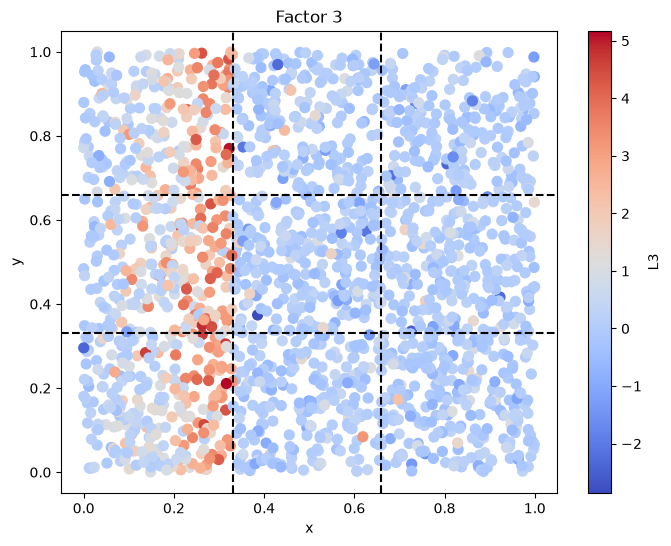

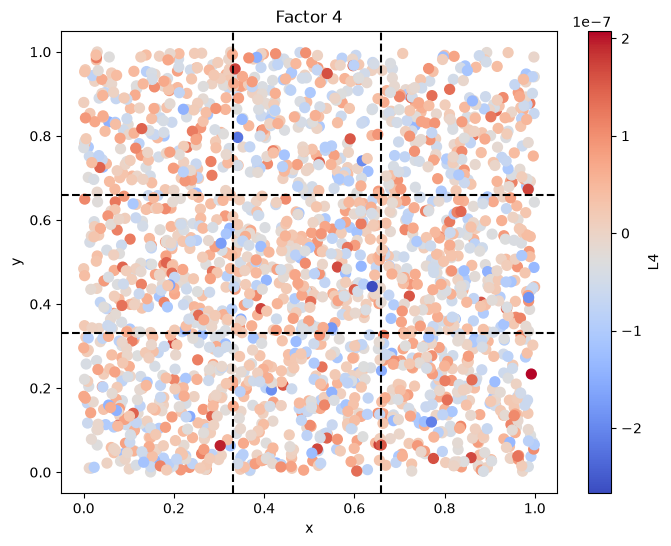

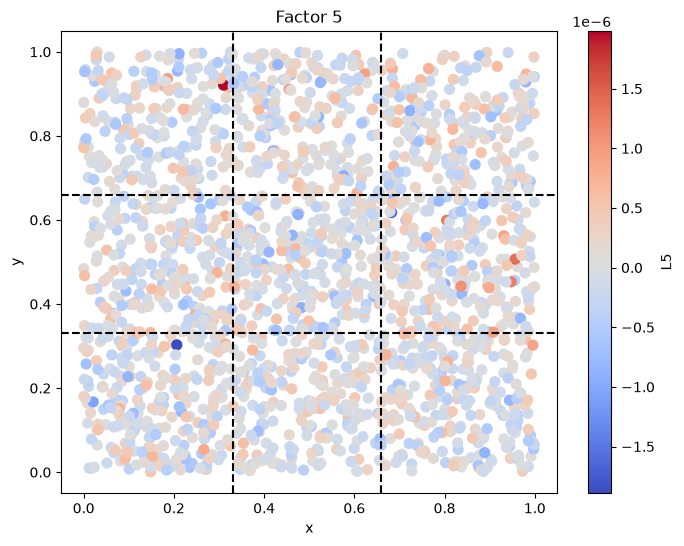

In [21]:
for i in range(5):
    plt.figure(figsize=(8,6))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=mycebmf.L[:, i].detach().cpu().numpy(),
        cmap="coolwarm",
        s=50
    )
    for v in [0.33, 0.66]:
        plt.axhline(v, color="black", linestyle="--")
        plt.axvline(v, color="black", linestyle="--")
    plt.title(f"Factor {i+1}")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar(label=f"L{i+1}")
    plt.show()


We can visulaized the fitted factor for the different prior 

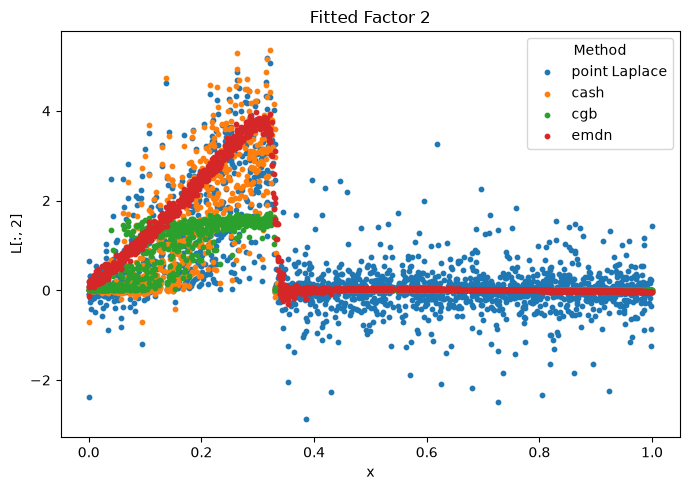

In [22]:
k = 2

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(x.detach().cpu().numpy(), mycebmf.L[:,k].detach().cpu().numpy(), s=10, label="point Laplace")
ax.scatter(x.detach().cpu().numpy(), mycebmf11.L[:,k].detach().cpu().numpy(), s=10, label="cash")
ax.scatter(x.detach().cpu().numpy(), mycebmf12.L[:,k].detach().cpu().numpy(), s=10, label="cgb")
ax.scatter(x.detach().cpu().numpy(), mycebmf13.L[:,k].detach().cpu().numpy(), s=10, label="emdn")

ax.set_title(f"Fitted Factor {k}")
ax.set_xlabel("x"); ax.set_ylabel(f"L[:, {k}]")
ax.legend(title="Method", loc="best")
plt.tight_layout()
plt.show()
